# **Machine Learning - Assignment**
### *Dataset: [Cat vs. Dog Image Classification](kaggle.com/datasets/tongpython/cat-and-dog/versions/1)*

**Course:** Machine Learning  
**Supervisor:** Truong Vinh Lan  
**Group 7**

| # | Member | Student Id |
|---|--------| ---------- |
| 1 | Nguyen Manh Quoc Khanh | 2352525 |
| 2 | Phan Ngoc Lan Chi | 2352137 |
| 3 | Ngo Diem Quyen | 2353031 |
| 4 | Tran Lam Anh | 2352067 |
| 5 | Vu Duc Viet Anh | 2352074 |

## **Overview**

This notebook implements a complete machine learning pipeline for binary image classification (Cat vs. Dog).

- **Classical Pipeline** - pretrained CNN backbone for feature extraction, followed by a traditional classifier (Logistic Regression, SVM, or Random Forest). Which will be implemented in this notebooks.
- **Deep Learning Pipeline** - end-to-end training with a pretrained CNN backbone and data augmentation. Which will be implemenented in another notebooks in the same folder with this notebooks.

Both pipelines share a common EDA and preprocessing stage. They diverge at the feature extraction and training steps, as illustrated below.

```
┌─────────────────────────────────────────────────────────────┐
│                      SHARED STAGES                          │
|-------------------------------------------------------------|
│                      Configuration                          │
|                            |                                |
|                            V                                |
│                           EDA                               |         
|                            |                                |
|                            V                                |
|                      Preprocessing                          |
└───────────────────────────┬─────────────────────────────────┘
                            │
              ┌─────────────┴─────────────┐
              V                           V
  ┌─────────────────────┐       ┌───────────────────────┐
  │   3. Classical      │       │  4. Deep Learning     │
  │      Pipeline       │       │     Pipeline          │
  |---------------------|       |-----------------------|
  │                     │       │                       │
  │ Feature Extraction  │       │  DataLoader + Augment │
  │  (pretrained CNN    │       │  (augmented mode)     │
  │   letterbox mode)   │       │          |            │
  │         |           |       |          V            |
  │         V           |       |      CNN Backbone     |
  │    Traditional      │       │   Feature Extraction  |
  │    Classifier       │       │          │            |
  │  (LR | SVM | RF)    │       │          V            |
  |         |           |       |  Classifier Training  |
  │         V           │       │          │            |
  │     Evaluation      │       │          V            |
  |                     |       |     Evaluation        │
  └──────────┬──────────┘       └──────────┬────────────┘
             │                             |
             └──────────────┬──────────────┘
                            V
                ┌────────────────────────┐
                │   5. Comparison &      │
                │      Summary           │
                └────────────────────────┘
```
The Comparison & Summary section will be mentioned in our report. Be mindful that this notebook will only implement the Classical Pipeline.

---
## **0. Configuration**

Edit **only** `USER_CONFIG` to change any experimental setting.
All downstream sections read from the merged `CONFIG` dict.
### 0.1 Environment setup

In [3]:
import os, sys, subprocess
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    REPO_URL = "https://github.com/kahn-29/252-MachineLearning-Assignment1.git"
    REPO_DIR = Path("/content/Submission")
    if not (REPO_DIR / "modules").exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    os.chdir(REPO_DIR)
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    print("Colab project root:", Path.cwd())
else:
    current_dir = Path.cwd()
    if current_dir.name == "notebooks":
        project_root = current_dir.parent
        if str(project_root) not in sys.path:
            sys.path.insert(0, str(project_root))
    print("Local environment. Current root:", Path.cwd())

from modules.config_utils import resolve_workspace, ensure_dirs

WORKSPACE = resolve_workspace(project_name="classical_pipeline")
FEATURE_DIR = WORKSPACE / "features"
FIGURE_DIR  = WORKSPACE / "figures"
MODEL_DIR   = WORKSPACE / "models"
ensure_dirs(FEATURE_DIR, FIGURE_DIR, MODEL_DIR)
print("Workspace:", WORKSPACE)

Local environment. Current root: /mnt/c/study/HK252/Machine Learning/assignment/252-MachineLearning-Assignment1/notebooks
Workspace: /mnt/c/study/HK252/Machine Learning/assignment/252-MachineLearning-Assignment1/notebooks/classical_pipeline




`CONFIG` centralizes the parameters that apply equally to both pipelines:

| Key | Sub-key | Default | Description |
|-----|---------|---------|-------------|
| `DATASET` | - | `tongpython/cat-and-dog` | Kaggle dataset identifier used by `kagglehub` |
| `CLEANING` | `blur_threshold` | `50.0` | Laplacian variance threshold; images below this value are considered blurry and discarded |
| `SPLIT` | `train` | `0.8` | Proportion of data allocated to the training set |
| | `val` | `0.1` | Proportion allocated to the validation set |
| | `test` | `0.1` | Proportion allocated to the test set |
| | `seed` | `42` | Random seed for reproducibility |
| `ENSEMBLE` | - | `False` | When `True`, trains all three classifiers for ensemble voting/stacking |

In [5]:
import collections.abc
from modules.config_utils import get_default_config, deep_update, set_seed, get_device

DEFAULT_CONFIG = get_default_config()
USER_CONFIG = {}
CONFIG = deep_update(DEFAULT_CONFIG, USER_CONFIG)

print("Configuration:")
for k,v in CONFIG.items():
    print(f"{k}: {v}")

SEED = CONFIG["SPLIT"]["seed"]
DEVICE = get_device()
set_seed(SEED)

print("Activate configuration: ")
print(f"Backbone: {CONFIG["CLASSICAL"]["backbone"]}")
print(f"Classifier: {CONFIG["CLASSICAL"]["classifier"]}")
print(f"Ensemble: {CONFIG["CLASSICAL"]["ENSEMBLE"]}")
print(f"Device: {DEVICE}")

Configuration:
DATASET: {'kaggle_id': 'tongpython/cat-and-dog'}
CLEANING: {'blur_laplacian_min': 40.0, 'min_side_min': 64, 'near_mono_ratio_max': 0.92, 'aspect_extremity_max': 5.0, 'remove_corrupted': True, 'remove_duplicates': False}
SPLIT: {'train': 0.8, 'val': 0.1, 'test': 0.1, 'seed': 42}
CLASSICAL: {'backbone': 'efficientnet_b0', 'preprocessing': 'letterbox', 'image_size': 224, 'batch_size': 64, 'classifier': 'logistic_regression', 'ENSEMBLE': False, 'lr_C': 1.0, 'svm_C': 1.0, 'rf_n_estimators': 200, 'rf_max_depth': None}
Activate configuration: 
Backbone: efficientnet_b0
Classifier: logistic_regression
Ensemble: False
Device: cpu


---
## **1. Exploratory Data Analysis (EDA)**

|Sub-section| Content | 
|-----------|---------|
| 1.1 Data setup | Download the dataset via `kagglehub` and building raw registry dataframe |
| 1.2 Class distribution | Class balance |
| 1.3 Spatial Characteristics | Analyzing width, height, and aspect ratio |
| 1.4 Spatial Outlier Detection | Identify and visualize extreme geometric outliers |
| 1.5 RGB Channel Analysis | Analyze color distributions to justify using CNN features |
| 1.6 Image Quality & Missing Values | Audit for blur, size, corruption, and missing metadata |
| 1.7 EDA Summary | Map key analytical findings to preprocessing decisions |


### 1.1 Dataset setup


### 1.1.1 Download dataset & build registry 

Dataset root:  /home/sunny/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1
Registry: 10,028 images
Classes: {'Dog': 5017, 'Cat': 5011}


,id,path,label,label_name
0,0,/home/sunny/.cache/kagglehub/datasets/tongpyth...,0,Cat
1,1,/home/sunny/.cache/kagglehub/datasets/tongpyth...,0,Cat
2,2,/home/sunny/.cache/kagglehub/datasets/tongpyth...,0,Cat
3,3,/home/sunny/.cache/kagglehub/datasets/tongpyth...,0,Cat
4,4,/home/sunny/.cache/kagglehub/datasets/tongpyth...,0,Cat


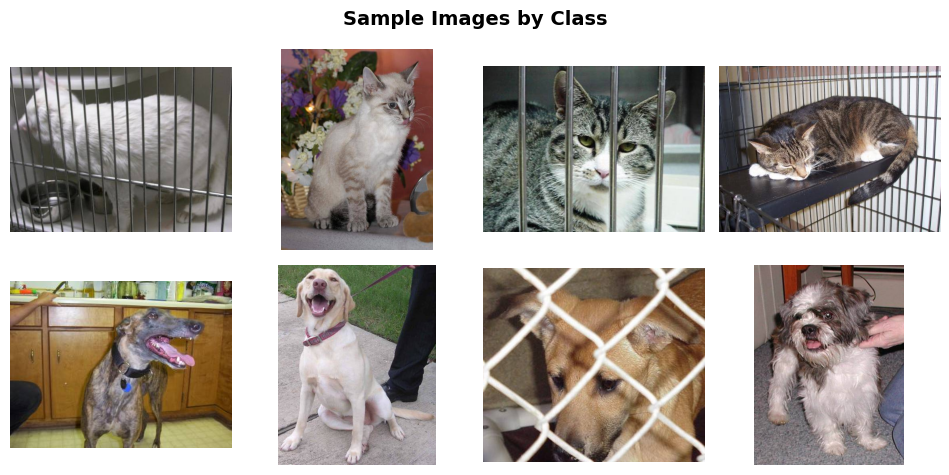

In [11]:
import pandas as pd
from modules.data_utils import resolve_dataset_root, build_raw_dataframe
from modules.visualization import plot_sample_grid

dataset_root = resolve_dataset_root(dataset_id=CONFIG["DATASET"]["kaggle_id"])
print("Dataset root: ", dataset_root)

df = build_raw_dataframe(dataset_root)
df.insert(0, "id", range(len(raw_df)))

print(f"Registry: {len(raw_df):,} images")
print(f"Classes: {df['label_name'].value_counts().to_dict()}")
display(df.head())

plot_sample_grid(
    df, 
    n_per_class=4, 
    seed=SEED, 
    save_path=FIGURE_DIR / "01_raw_samples.png"
)

### 1.1.2 Raw Folder Structure

Before building the registry, we inspect the archive layout. The output confirms a doubly-nested directory convention - e.g. `training_set/training_set/cats/` - which must be accounted for when constructing file paths programmatically.

```
cat-and-dog/
  test_set/test_set/
    cats/   (1,012 files)
    dogs/   (1,013 files)
  training_set/training_set/
    cats/   (4,001 files)
    dogs/   (4,006 files)
```

In [12]:
import os

def list_structure(startpath: str, max_files: int = 3) -> None:
    """Print a compact directory tree, showing at most *max_files* per folder."""
    print(f"Directory tree: {startpath}\n")
    for root, dirs, files in os.walk(startpath):
        level  = root.replace(startpath, "").count(os.sep)
        indent = "    " * level
        print(f"{indent}[{os.path.basename(root)}/]")
        sub = "    " * (level + 1)
        for f in files[:max_files]:
            print(f"{sub}- {f}")
        if len(files) > max_files:
            print(f"{sub}... ({len(files)} files total)")

list_structure(str(dataset_root))


Directory tree: /home/sunny/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1

[1/]
    [test_set/]
        [test_set/]
            [dogs/]
                - dog.4835.jpg
                - dog.4103.jpg
                - dog.4814.jpg
                ... (1013 files total)
            [cats/]
                - cat.4417.jpg
                - cat.4687.jpg
                - cat.4754.jpg
                ... (1012 files total)
    [training_set/]
        [training_set/]
            [dogs/]
                - dog.81.jpg
                - dog.543.jpg
                - dog.2675.jpg
                ... (4006 files total)
            [cats/]
                - cat.3619.jpg
                - cat.678.jpg
                - cat.3565.jpg
                ... (4001 files total)


### 1.2 Class Distribution

Check if the dataset is imbalanced to determine whether strategies like class-weighting or oversampling are necessary

In [ ]:
from modules.visualization import plot_class_distribution_bar, plot_class_distribution_pie

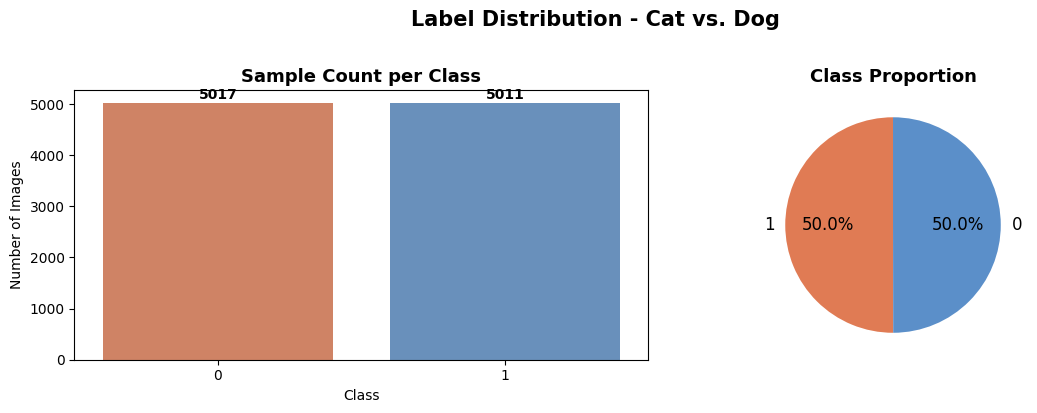

label
1    5017
0    5011


KeyError: 'cat'

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Bar chart ---
class_counts = df["label"].value_counts()
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=["#e07b54", "#5b8fc9"],
    ax=axes[0],
    legend=False
)
axes[0].set_title("Sample Count per Class", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].set_xlabel("Class")

for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30, str(val),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Pie chart ---
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", colors=["#e07b54", "#5b8fc9"],
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Label Distribution - Cat vs. Dog", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(class_counts.to_string())
print(f"\nBalance ratio (cat/dog): {class_counts['cat'] / class_counts['dog']:.4f}")


The dataset is **near-perfectly balanced**: dog images account for 5,017 samples and cat images for 5,011, yielding a balance ratio of **0.9988**.

Both the bar chart and pie chart confirm that each class occupies exactly **50.0%** of the dataset. This level of balance means that:

- **No resampling strategy is required** (e.g. oversampling, undersampling, ...).
- **No class-weighted loss function is needed** during model training, as neither class will dominate the gradient updates.
- **Accuracy is a reliable evaluation metric** for this dataset - a trivial majority-class classifier would only achieve 50%, providing a meaningful baseline.

Overall, the class distribution presents no concerns and requires no corrective action before proceeding to the next stage.

### 1.7 Descriptive Statistics of Image Dimensions

To inform preprocessing parameter selection, descriptive statistics (mean, std, min, max, and quartiles) are computed separately for each class (cat / dog) across three dimension attributes: pixel width, height, and aspect ratio (W/H).

In [ ]:
numeric_cols = ["width", "height", "ratio"]

print("=" * 55)
print("  DESCRIPTIVE STATISTICS - IMAGE DIMENSIONS")
print("=" * 55)

grouped = df.groupby("label")[numeric_cols].describe()
for col in numeric_cols:
    print(f"\n-- {col.upper()} --")
    display(
        grouped[col][["mean", "std", "min", "25%", "50%", "75%", "max"]]
        .style.format("{:.2f}")
        .background_gradient(cmap="Blues")
    )


Both classes exhibit similar spatial characteristics: mean width hovers around 400 px and mean height around 360 px, each with a standard deviation of ~100 px - reflecting considerable resolution variability across the dataset. Aspect ratios are close to 1.19 (cat) and 1.12 (dog) on average, meaning most images are slightly wider than tall. The large max values (width up to 1050 px, ratio up to 5.91) suggest the presence of extreme outliers that will be addressed in the outlier removal step.

### 1.8 Spatial Distribution - Width, Height & Aspect Ratio

Overlapping histograms with KDE (Kernel Density Estimation) curves are plotted for width, height, and aspect ratio, with each class rendered in a distinct color. A vertical reference line at ratio = 1.0 marks the square-image threshold. All three plots share a consistent layout to facilitate cross-attribute comparison.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"cat": "#e07b54", "dog": "#5b8fc9"}

for col, ax, xlabel in zip(
    ["width", "height", "ratio"],
    axes,
    ["Width (px)", "Height (px)", "Aspect Ratio (W/H)"],
):
    for lbl, grp in df.groupby("label"):
        sns.histplot(grp[col].dropna(), bins=50, kde=True,
                     color=colors[lbl], label=lbl, alpha=0.55, ax=ax)
    if col == "ratio":
        ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="1:1")
    ax.set_title(f"{col.capitalize()} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Spatial Characteristics of the Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Both cat and dog classes show nearly identical distributions across all three spatial attributes. Width is right-skewed with a sharp peak around 450 px, while height displays a bimodal pattern with two prominent peaks near 350 px and 500 px. Aspect ratios are concentrated just above 1.0, confirming that most images are slightly wider than tall. The near-perfect overlap between the two classes indicates that image resolution and framing are not class-discriminative features.

### 1.9 Spatial Outlier Detection

A scatter plot of width vs. height is drawn separately for each class. Images whose width or height exceeds 3 standard deviations from the class mean are flagged as spatial outliers and highlighted in red, while the remaining images are shown in the class color. This visualization helps identify samples with atypical resolutions that may introduce excessive geometric distortion during the resize step.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Cat Images", "Dog Images"]
labels = ["cat", "dog"]
palette = [["#e07b54", "#f4a582"], ["#5b8fc9", "#92c5de"]]

for ax, lbl, (c1, c2), title in zip(axes, labels, palette, titles):
    sub = df[df["label"] == lbl].dropna(subset=["width", "height"])
    ax.scatter(sub["width"], sub["height"], alpha=0.3, s=8, color=c1)

    # Mark extreme outliers (beyond 3 standard deviations in either dimension)
    mu_w, sd_w = sub["width"].mean(),  sub["width"].std()
    mu_h, sd_h = sub["height"].mean(), sub["height"].std()
    outliers = sub[
        (sub["width"]  > mu_w + 3 * sd_w) |
        (sub["height"] > mu_h + 3 * sd_h)
    ]
    ax.scatter(outliers["width"], outliers["height"],
               color="red", s=25, label=f"Outliers (n={len(outliers)})", zorder=5)

    ax.set_title(f"W x H Scatter - {title}", fontweight="bold")
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)

plt.suptitle("Spatial Outlier Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Both classes contain only one spatial outlier each, appearing in the upper-right corner of the scatter plot - images with exceptionally large dimensions compared to the rest of the dataset. The majority of images are concentrated within a width range of 100-500 px and height range of 50-500 px, indicating a consistent size distribution across both classes. The negligible outlier count (0.2%) confirms that the dataset is largely free of extreme resolution anomalies.

### 1.10 RGB Channel Analysis

Per-channel mean pixel intensities are extracted from a stratified random sample of 2,000 images. Comparing the resulting distributions across classes reveals whether colour statistics alone provide a discriminative signal - or whether spatial and structural features are necessary for classification.

A stratified random sample of 2,000 images is drawn from the dataset. For each image,
the file is read with OpenCV, converted from BGR to RGB, then the mean pixel intensity
of each channel (R, G, B) is computed by averaging over all pixels. The resulting
per-channel means are stored as new columns in the sample DataFrame.

Summary statistics (mean, std, min, max) are then displayed grouped by class.
Additionally, KDE plots are drawn separately for each class, overlaying the three
channel distributions on the same axes to visualize how pixel intensity is spread
across R, G, and B channels for cat and dog images respectively.

In [ ]:
import cv2
import numpy as np

SAMPLE_N = min(2000, len(df))  # Cap at 2000 to keep runtime reasonable
df_sample = df.sample(n=SAMPLE_N, random_state=42).copy()

r_means, g_means, b_means = [], [], []

for path_str in tqdm(df_sample["path"], desc="Extracting RGB stats"):
    try:
        img  = cv2.imread(path_str)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean = np.mean(img, axis=(0, 1))
        r_means.append(mean[0])
        g_means.append(mean[1])
        b_means.append(mean[2])
    except Exception:
        r_means.append(None)
        g_means.append(None)
        b_means.append(None)

df_sample["R_mean"] = r_means
df_sample["G_mean"] = g_means
df_sample["B_mean"] = b_means

print("\n-- RGB Mean Statistics (sampled) --")
display(
    df_sample.groupby("label")[["R_mean", "G_mean", "B_mean"]]
    .describe()
    .loc[:, (slice(None), ["mean", "std", "min", "max"])]
    .style.format("{:.2f}")
)


Both classes show very similar mean pixel intensities across all three channels -  the R channel is highest (around 122-125), followed by G (around 114-117), and B lowest (106-107). Standard deviations hover around 28-30 for all channels, indicating comparable color variability between cat and dog images. The marginal differences between the two classes suggest that color statistics alone are insufficient to discriminate between the two classes.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
channel_cfg = [("R_mean", "red"), ("G_mean", "green"), ("B_mean", "blue")]

for ax, lbl in zip(axes, ["cat", "dog"]):
    sub = df_sample[df_sample["label"] == lbl].dropna()
    for col, color in channel_cfg:
        sns.kdeplot(sub[col], color=color, label=color.capitalize(),
                    fill=True, alpha=0.15, ax=ax)
    ax.set_title(f"RGB Channel Distribution — {lbl.upper()}", fontweight="bold")
    ax.set_xlabel("Mean Pixel Intensity (0–255)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Per-Channel Colour Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


The R, G, and B channel distributions for both classes follow a roughly normal shape, concentrated in the 80-150 intensity range. In both cat and dog, the R channel exhibits a longer right tail compared to G and B, reflecting a warm color tone bias across the dataset. Notably, the distributions of the two classes overlap almost perfectly, confirming that color is not a discriminative feature - the model will need to rely on shape and spatial structure features for effective classification.

### 1.11 Missing Value Audit

The four metadata columns - width, height, channels, and ratio - are checked for null values. The total missing count and percentage are computed for each column and displayed as a summary table. If no missing values are found, a success message is printed; otherwise, a warning is raised and the IDs of corrupt images (those with a null width) are listed for further inspection.

In [ ]:
missing = df[["width", "height", "channels", "ratio"]].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
})
print(summary.to_string())

if missing.sum() == 0:
    print("\n[SUCCESS] No missing values - all images were read successfully.")
else:
    print(f"\n[WARNING] {missing.sum()} missing entries detected.")
    corrupt_ids = df[df["width"].isnull()]["id"].tolist()
    print(f"   Corrupt image IDs: {corrupt_ids[:10]} ...")


All four metadata columns (width, height, channels, ratio) contain zero missing values, meaning every image in the dataset was read and processed successfully with no corrupt or unreadable files detected.

### **EDA Summary**


The table below consolidates key findings from Sections 1.5-1.10 and maps each
observation to a concrete preprocessing decision.

| # | Finding | Evidence | Preprocessing Decision |
|---|---------|----------|----------------------|
| 1 | Balanced classes | cat: 5,011 / dog: 5,017 (ratio 0.9988) | No class weighting or oversampling required |
| 2 | High resolution variability | Width std ≈ 108 px, height std ≈ 97 px; range 33 px => 1,050 px | Resize all images to a fixed target size (224 x 224) |
| 3 | Slightly wider than tall | Mean aspect ratio ≈ 1.19 (cat), 1.12 (dog) | Use letterbox padding to preserve aspect ratio during resize |
| 4 | Bimodal height distribution | Two peaks at ~350 px and ~500 px | Consistent with mixed-source images; fixed resize handles this |
| 5 | Negligible spatial outliers | 1 outlier per class detected (2 total) | Remove images exceeding 3 standard deviation bounds in width or height |
| 6 | No color discriminability | R/G/B means nearly identical across classes | Color normalization applied; model must rely on shape features |
| 7 | No missing values | 0 nulls across all metadata columns | No imputation needed; all images are valid for further processing |

---
## **2. Preprocessing Pipeline**

This section implements preprocessing steps that are **shared across both pipelines**.
The output of this section - a cleaned, split, and transformed dataset - serves as
the common input for both the Classical Pipeline (Section 3) and the
Deep Learning Pipeline (Section 4).

| Step | Classical Pipeline | Deep Learning Pipeline |
|------|--------------------|------------------------|
| Cleaning | shared | shared |
| Outlier removal | shared | shared |
| Train/val/test split | shared | shared |
| Resize & normalize | `letterbox` mode | `augmented` mode (train only) |

> To switch between preprocessing modes, adjust `PIPELINE.preprocessing` in
> Section 0 Configuration before re-running this section.


### 2.1 Support Module

The `image_preprocessor.py` module is written to a standalone file using `%%writefile` so that it can be **imported in subsequent sections** without redefining its contents. This module serves as the backbone of the entire image preprocessing pipeline, consisting of 5 sequential stages:

| Stage | Name | Description |
|-------|------|-------------|
| 1 | **Data Collection** | Recursively walks source directories, collects image file paths, and automatically assigns labels based on folder names (`cat` / `dog`) |
| 2 | **Cleaning** | Discards low-quality images **before** any expensive processing - rejects blurry images (Laplacian variance < 40), undersized images (< 64 px), and corrupt or near-monochrome images (> 95% near-black or near-white pixels) |
| 3 | **Label Encoding** | Maps string class names (`"cat"`, `"dog"`) to integer indices (`0`, `1`) using `LabelEncoder` - the fitted encoder is retained as a class attribute for decoding predictions later |
| 4 | **Dataset Split** | Partitions the dataset using a stratified **80 / 10 / 10** (train / val / test) split - guaranteeing that the class ratio is preserved across all three subsets |
| 5 | **Transformation** | Resizes each image to a fixed `224 × 224` resolution using letterbox `pad` mode (aspect-ratio-preserving) and normalises pixel values to `[0.0, 1.0]` |

> **Note:** The `ImagePipeline` class accepts an optional `config` dictionary at initialisation. Any parameter not explicitly provided will fall back to its default value defined in `DEFAULT_CONFIG`.

In [ ]:
%%writefile image_preprocessor.py
"""
image_preprocessor.py
---------------------
Binary image classification pre-processing pipeline (dog vs. cat).

Stages
------
1. Data collection  - recursively walk raw source directories and gather
                      image paths with their ground-truth labels.
2. Cleaning         - discard blurry, corrupt, undersized, or near-monochrome
                      images before any expensive processing occurs.
3. Label encoding   - map string class names to integer indices.
4. Dataset split    - stratified 80 / 10 / 10 train / val / test partition.
5. Transformation   - resize + normalise each image to a fixed NumPy array.
"""

from __future__ import annotations

import os
from typing import Any

import cv2
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

class ImagePipeline:
    """End-to-end pre-processing pipeline for binary (dog / cat) image datasets."""

    def __init__(self, config: dict[str, Any] | None = None) -> None:
        self.config: dict[str, Any] = config or {}
        self.label_encoder: LabelEncoder | None = None

    def _is_blurry(self, img_path: str) -> bool:
        try:
            gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if gray is None:
                return True
            return cv2.Laplacian(gray, cv2.CV_64F).var() < self.config["CLEANING"]["blur_threshold"]
        except Exception:
            return True

    def _is_too_small(self, img_path: str) -> bool:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                return w < self.config["min_w"] or h < self.config["min_h"]
        except Exception:
            return True

    def _is_corrupt_or_near_monochrome(self, img_path: str) -> bool:
        try:
            img = cv2.imread(img_path)
            if img is None:
                return True
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            total = gray.size
            r = self.config["near_mono_ratio"]
            near_black = np.sum(gray <= pipeline.config["CLEANING"]["black_pixel_cap"]) / total
            near_white = np.sum(gray >= pipeline.config["CLEANING"]["white_pixel_floor"]) / total
            return near_black > r or near_white > r
        except Exception:
            return True

    def transform_image(self, img_path: str) -> np.ndarray | None:
        try:
            img = Image.open(img_path).convert("RGB")
            target_size = self.config["target_size"]
            mode = self.config["resize_mode"]
            if mode == "direct":
                img = img.resize(target_size, Image.BILINEAR)
            elif mode in ("pad", "augmented"):
                # Letterbox resize (shared by both pad and augmented)
                img.thumbnail(target_size, Image.LANCZOS)
                canvas = Image.new("RGB", target_size, (0, 0, 0))
                canvas.paste(img, ((target_size[0] - img.size[0]) // 2,
                                   (target_size[1] - img.size[1]) // 2))
                img = canvas
                # Augmentation - only applied when mode == "augmented"
                if mode == "augmented":
                    import random
                    from PIL import ImageEnhance
                    if random.random() > 0.5:
                        img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(Image.FLIP_TOP_BOTTOM)
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Saturation(img).enhance(random.uniform(0.8, 1.2))
            else:
                raise ValueError(f"Unsupported resize_mode '{mode}'.")
            arr = np.array(img, dtype=np.float32)
            if self.config.get("normalize", True):
                arr /= 255.0
            return arr
        except ValueError:
            raise
        except Exception:
            return None

    def _encode_labels(self, labels: list[str]) -> tuple[np.ndarray, np.ndarray]:
        self.label_encoder = LabelEncoder()
        encoded = self.label_encoder.fit_transform(labels)
        return encoded, self.label_encoder.classes_

    def _gather_all_files(self, raw_paths: list[str]) -> tuple[list[str], list[str]]:
        all_files, labels = [], []
        for root_path in raw_paths:
            for root, _, files in os.walk(root_path):
                folder = os.path.basename(root).lower()
                if "cat" in folder:
                    label = "cat"
                elif "dog" in folder:
                    label = "dog"
                else:
                    continue
                for f in files:
                    if f.lower().endswith((".jpg", ".jpeg", ".png")):
                        all_files.append(os.path.join(root, f))
                        labels.append(label)
        return all_files, labels

In [ ]:
from image_preprocessor import ImagePipeline

### 2.2 Data Cleaning

Three quality filters are applied sequentially to every image. Each filter computes a continuous **score** rather than a binary flag, enabling post-hoc threshold tuning and visual validation.

| Filter | Score metric | Rejection criterion |
|--------|-------------|---------------------|
| Near-monochrome | Max fraction of near-black (≤ 10) or near-white (≥ 245) pixels | score ≥ 0.95 |
| Undersized | Minimum dimension - `min(width, height)` | score < 64 px |
| Blurry | Laplacian variance of the grayscale image | score < 40 |

An image is rejected on the **first** criterion it fails; subsequent filters are not evaluated. The `rejected_by` field records the cause for each discarded sample.

In [ ]:
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

pipeline = ImagePipeline(CONFIG)
n_before = len(df)

# -- Scoring functions - each returns a float comparable against its threshold -

def score_monochrome(path_str: str) -> float:
    """Near-monochrome score: max fraction of near-black or near-white pixels. Threshold = 0.95"""
    try:
        img = cv2.imread(path_str)
        if img is None:
            return 1.0   # File unreadable - assign worst-case score
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        total = gray.size
        # Access config parameters via pipeline.config
        near_black = np.sum(gray <= pipeline.config["CLEANING"]["black_pixel_cap"]) / total
        near_white = np.sum(gray >= pipeline.config["CLEANING"]["white_pixel_floor"]) / total
        return float(max(near_black, near_white))
    except Exception:
        return 1.0

def score_size(path_str: str) -> float:
    """Minimum-dimension score: min(width, height) in pixels. Lower = smaller. Threshold = 64 px"""
    try:
        with Image.open(path_str) as img:
            return float(min(img.size))   # min(width, height)
    except Exception:
        return 0.0

def score_blur(path_str: str) -> float:
    """Blur score: Laplacian variance of the grayscale image. Lower = blurrier. Threshold = 40"""
    try:
        gray = cv2.imread(path_str, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            return 0.0
        return float(cv2.Laplacian(gray, cv2.CV_64F).var())
    except Exception:
        return 0.0

MONO_THRESH = pipeline.config["CLEANING"]["mono_threshold"]
SIZE_THRESH = pipeline.config["CLEANING"]["min_size"]
BLUR_THRESH = pipeline.config["CLEANING"]["blur_threshold"]

records_scored = []

for path_str in tqdm(df["path"], desc="Scoring & Cleaning"):
    mono = score_monochrome(path_str)
    size = score_size(path_str)
    blur = score_blur(path_str)

    rejected_by = None
    if mono  >= MONO_THRESH:  rejected_by = "monochrome"
    elif size < SIZE_THRESH:  rejected_by = "too_small"
    elif blur < BLUR_THRESH:  rejected_by = "blurry"

    records_scored.append({
        "path": path_str,
        "score_mono": mono,
        "score_size": size,
        "score_blur": blur,
        "rejected_by": rejected_by,   # None -> passes all filters
    })

df_scored  = pd.DataFrame(records_scored)
df_clean   = df[df_scored["rejected_by"].isna()].reset_index(drop=True)
df_rejected = df_scored[df_scored["rejected_by"].notna()].copy()

n_removed = n_before - len(df_clean)
print(f"\nBefore cleaning : {n_before:,} images")
print(f"After  cleaning : {len(df_clean):,} images")
print(f"Removed : {n_removed:,}  ({n_removed / n_before * 100:.1f}%)")
print(f"\nBreakdown:")
print(df_rejected["rejected_by"].value_counts().to_string())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def show_rejection_spectrum(df_rej: pd.DataFrame, reason: str, score_col: str,
                             ascending: bool, threshold: float, n_cols: int = 5):
    """
    Display a 3-row grid of rejected images for a single rejection reason,
    ordered by severity to support visual threshold validation.

    Row 1 - Most rejected : samples with the worst scores (clearly should be removed).
    Row 2 - Borderline    : samples nearest the threshold (most informative for tuning).
    Row 3 - Mid-range     : representative samples from the middle of the score distribution.

    Parameters
    ----------
    ascending : bool — True  → lower score = worse (blur, size).
                       False → higher score = worse (monochrome).
    """
    subset = df_rej[df_rej["rejected_by"] == reason].copy()
    if subset.empty:
        print(f"No rejected images for reason: {reason}")
        return

    # Sort from worst to least-bad along the relevant score axis
    subset_sorted = subset.sort_values(score_col, ascending=ascending).reset_index(drop=True)
    n = len(subset_sorted)

    # Select representative indices for each display row
    worst_idx = list(range(min(n_cols, n)))
    border_idx = sorted(range(n), key=lambda i: abs(subset_sorted.loc[i, score_col] - threshold))[:n_cols]
    mid_start = max(0, n // 2 - n_cols // 2)
    mid_idx = list(range(mid_start, min(mid_start + n_cols, n)))

    groups = [
        ("Most Rejected", worst_idx, "#d62728"),
        ("Borderline (near threshold)", border_idx, "#ff7f0e"),
        ("Mid-range", mid_idx, "#2ca02c"),
    ]

    title_map = {
        "monochrome": f"Rejection Reason: MONOCHROME | threshold ≥ {threshold}",
        "too_small": f"Rejection Reason: TOO SMALL | threshold < {threshold} px",
        "blurry": f"Rejection Reason: BLURRY | threshold < {threshold}",
    }

    fig, axes = plt.subplots(3, n_cols, figsize=(n_cols * 3, 10))
    fig.suptitle(title_map.get(reason, reason), fontsize=14, fontweight="bold", y=1.01)

    for row_idx, (row_label, indices, row_color) in enumerate(groups):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            if col_idx < len(indices):
                entry = subset_sorted.iloc[indices[col_idx]]
                try:
                    img = Image.open(entry["path"]).convert("RGB")
                    ax.imshow(img)
                    score_val = entry[score_col]
                    ax.set_title(f"{score_col}={score_val:.3f}", fontsize=8, color=row_color)
                except Exception:
                    ax.text(0.5, 0.5, "ERR", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")

            # Row label in first column
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=9, fontweight="bold",
                              color=row_color, rotation=0, labelpad=120, va="center")

    plt.tight_layout()
    plt.show()
    print(f"  [{reason}] total rejected: {n}  |  score range: "
          f"[{subset_sorted[score_col].min():.3f}, {subset_sorted[score_col].max():.3f}]  "
          f"|  threshold: {threshold}\n")


# -------- Run visualisation for each active rejection reason -----------
print(f"Total rejected: {len(df_rejected)}  |  Reasons: {df_rejected['rejected_by'].unique().tolist()}\n")

show_rejection_spectrum(df_rejected, "monochrome", "score_mono",
                        ascending=False, threshold=MONO_THRESH)

show_rejection_spectrum(df_rejected, "too_small", "score_size",
                        ascending=True,  threshold=SIZE_THRESH)

show_rejection_spectrum(df_rejected, "blurry", "score_blur",
                        ascending=True,  threshold=BLUR_THRESH)

#### **Cleaning Results**

Of the 10,028 images in the original registry, **264 were rejected (2.6%)**, leaving **9,764 images** after cleaning.

| Rejection Reason | Count | % of Total |
|-----------------|-------|------------|
| Blurry (Laplacian variance < 40) | 248 | 2.47% |
| Too small (min dimension < 64 px) | 16 | 0.16% |
| Near-monochrome | 0 | 0.00% |

Blur accounts for **94%** of all rejected samples, consistent with the dataset containing real-world photographs of varying photographic quality. The complete absence of near-monochrome rejections confirms there are no solid-colour placeholder images in the archive. The blurry score range of [6.75, 39.77] - entirely below the threshold of 40 - indicates that all rejected images are genuinely low-contrast rather than borderline cases, suggesting the current threshold is well-calibrated.

### 2.3 Spatial Outlier Removal

Images whose width or height lies beyond **3 standard deviations** from the per-dimension mean are removed. This filter targets samples with atypical resolutions that would require extreme scaling during the resize step, potentially introducing artefacts that degrade feature quality.

In [ ]:
# Compute 3-sigma bounds from clean set
for col in ["width", "height"]:
    mu, sd = df_clean[col].mean(), df_clean[col].std()
    lo, hi = mu - 3 * sd, mu + 3 * sd
    df_clean = df_clean[(df_clean[col] >= lo) & (df_clean[col] <= hi)]

df_clean = df_clean.reset_index(drop=True)
print(f"After outlier removal: {len(df_clean):,} images")


#### **Outlier Removal Result:**

The 3 standard deviations filter removed an additional **8 images** (9,764 -> **9,756**), representing 0.08% of the post-cleaning pool. The small count is consistent with EDA findings: while a handful of images exceeded 1,000 px in one dimension, the vast majority of the dataset clustered tightly around the mean resolution.

### 2.4 Stratified Train / Validation / Test Split

The cleaned dataset is partitioned into three non-overlapping subsets using stratified sampling, which guarantees that the cat-to-dog ratio is reproduced in every split. The validation set is used for hyperparameter tuning; the test set is held out until final model evaluation.

| Split | Fraction | Purpose |
|-------|----------|---------|
| Train | 80% | Model fitting |
| Validation | 10% | Hyperparameter tuning |
| Test | 10% | Final held-out evaluation |

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean["path"].values
y = df_clean["label_encoded"].values

# 80 % train - 20 % temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# 50/50 split of the 20 % => 10 % val + 10 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    cats = (y_split == 0).sum()
    dogs = (y_split == 1).sum()
    print(f"{name:5s}  total={len(y_split):5d}  cat={cats:5d}  dog={dogs:5d}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_data = [("Train", y_train), ("Validation", y_val), ("Test", y_test)]
colors = ["#5b8fc9", "#e07b54"]

for ax, (name, y_split) in zip(axes, split_data):
    counts = [int((y_split == 0).sum()), int((y_split == 1).sum())]
    ax.bar(["cat", "dog"], counts, color=colors)
    ax.set_title(f"{name} Set (n={len(y_split)})", fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Class Balance Across Dataset Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### **Split Result**

| Split | Total | Cat | Dog | Cat% |
|-------|-------|-----|-----|------|
| Train | 6,829 | 3,378 | 3,451 | 49.5% |
| Validation | 1,463 | 724 | 739 | 49.5% |
| Test | 1,464 | 724 | 740 | 49.5% |

Stratification is successful: the cat proportion is consistently **49.5%** across all three splits, confirming no split is skewed toward either class.

### 2.5 Image Transformation - Resize & Normalisation

Images are transformed differently depending on the target pipeline:

- **Classical Pipeline** uses `letterbox` (pad) mode - aspect-ratio-preserving resize with black padding, no augmentation. This produces stable, deterministic feature vectors suitable for traditional classifiers.
- **Deep Learning Pipeline** uses `augmented` mode on the training split - applies random flips, colour jitter, and rotation to improve generalisation. Validation and test splits still use `letterbox`.

Both modes resize to `224 x 224` and normalise pixel values to `[0, 1]`. To manage Colab RAM, images are processed and saved in batches of 1,000 as `.npy` files.

<!-- Each image undergoes a two-step transformation before being persisted to disk:

1. **Resize to 224 × 224** using letterbox padding - aspect-ratio-preserving thumbnail scaling followed by centre-placement on a black canvas. This avoids the geometric distortion of direct squash resizing, which is particularly harmful for pet images where body proportions are a meaningful feature.

2. **Normalisation to [0, 1]** by dividing pixel values by 255, bringing the input distribution into a range compatible with standard pretrained model conventions.

To avoid exhausting Colab RAM, images are processed and written in batches of 1,000. Each batch is saved as a pair of `.npy` files (`{split}_X_{batch_id}.npy` and `{split}_y_{batch_id}.npy`).

> **Pipeline flexibility:** `target_size` can be changed to (299, 299) for InceptionV3 or EfficientNet-B4; `resize_mode` can be switched to `"direct"` for a speed/quality trade-off comparison. -->

In [ ]:
import gc

BATCH_SIZE = 1000

def process_and_save_to_disk(
    paths: np.ndarray,
    labels: np.ndarray,
    split_name: str,
    config: dict,
    output_dir: str,
    batch_size: int = BATCH_SIZE,
) -> None:
    from image_preprocessor import ImagePipeline
    pipe = ImagePipeline(config)

    n = len(paths)
    os.makedirs(output_dir, exist_ok=True)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        b_paths  = paths[start:end]
        b_labels = labels[start:end]
        X_batch, y_batch = [], []

        for p, lbl in tqdm(
            zip(b_paths, b_labels),
            total=len(b_paths),
            desc=f"  {split_name} batch {start // batch_size}",
        ):
            arr = pipe.transform_image(p)
            if arr is not None:
                X_batch.append(arr)
                y_batch.append(lbl)

        batch_id = start // batch_size
        np.save(f"{output_dir}/{split_name}_X_{batch_id}.npy", np.array(X_batch, dtype=np.float32))
        np.save(f"{output_dir}/{split_name}_y_{batch_id}.npy", np.array(y_batch, dtype=np.int32))

        del X_batch, y_batch
        gc.collect()

    print(f"[OK] {split_name}: saved {n} images in {(n - 1) // batch_size + 1} batch(es)")

#### 2.5.1 Classical Pipeline - Letterbox Transformation

In [ ]:
import gc

CLASSICAL_CONFIG = {
    "target_size": (224, 224),
    "resize_mode": "pad",       # letterbox
    "normalize":   True,
    "remove_outlier": False,
    "outlier_config": None,
}

CLASSICAL_BATCH_DIR = "./processed_batches/classical"
os.makedirs(CLASSICAL_BATCH_DIR, exist_ok=True)

print("Starting Classical transformation (letterbox)...")
for split_name, paths, labels in [
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test),
]:
    process_and_save_to_disk(paths, labels, split_name, CLASSICAL_CONFIG, CLASSICAL_BATCH_DIR)

print("\n[SUCCESS] Classical batches saved to:", CLASSICAL_BATCH_DIR)

#### 2.5.2 Deep Learning Pipeline - Augmented Transformation

In [ ]:
DL_CONFIG_TRAIN = {
    "target_size": (224, 224),
    "resize_mode": "augmented",  # augmentation on train only
    "normalize":   True,
    "remove_outlier": False,
    "outlier_config": None,
}

DL_CONFIG_EVAL = {
    "target_size": (224, 224),
    "resize_mode": "pad",        # letterbox for val & test
    "normalize":   True,
    "remove_outlier": False,
    "outlier_config": None,
}

DL_BATCH_DIR = "./processed_batches/deep_learning"
os.makedirs(DL_BATCH_DIR, exist_ok=True)

print("Starting Deep Learning transformation (augmented train / letterbox val & test)...")
process_and_save_to_disk(X_train, y_train, "train", DL_CONFIG_TRAIN, DL_BATCH_DIR)
process_and_save_to_disk(X_val,   y_val,   "val",   DL_CONFIG_EVAL,  DL_BATCH_DIR)
process_and_save_to_disk(X_test,  y_test,  "test",  DL_CONFIG_EVAL,  DL_BATCH_DIR)

print("\n[SUCCESS] Deep Learning batches saved to:", DL_BATCH_DIR)

#### **Transformation Result**

All splits were processed and saved to `./processed_batches/classical` and `./processed_batches/deep_learning` respectively.

| Split | Images | Batches | Classical output files | Deep Learning output files |
|-------|--------|---------|----------------------|---------------------------|
| Train | 7804 | 8 | `train_X_0..7.npy` + `train_y_0..7.npy` | `train_X_0..7.npy` + `train_y_0..7.npy` |
| Validation | 976 | 1 | `val_X_0.npy` + `val_y_0.npy` | `val_X_0.npy` + `val_y_0.npy` |
| Test | 976 | 1 | `test_X_0.npy` + `test_y_0.npy` | `test_X_0.npy` + `test_y_0.npy` |

### 2.6 Sanity Check - Visual Verification

Ten random samples are loaded from the first training batch and rendered alongside their predicted class labels. This confirms that (a) the `.npy` files were written correctly, (b) letterbox padding is applied and centred, and (c) label indices map to the expected class names.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load first train batch for quick visual sanity check
X_check = np.load(f"{CLASSICAL_BATCH_DIR}/train_X_0.npy")
y_check = np.load(f"{CLASSICAL_BATCH_DIR}/train_y_0.npy")
CLASS_NAMES = le.classes_   # ['cats', 'dogs']

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
indices   = np.random.choice(len(X_check), 10, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X_check[idx])
    ax.set_title(f"ID {idx} - {CLASS_NAMES[y_check[idx]]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Preprocessed Images (Normalised to [0,1])",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Batch shape: {X_check.shape}  (N, H, W, C)")
print(f"Value range: [{X_check.min():.4f}, {X_check.max():.4f}]")
print(f"dtype: {X_check.dtype}")


In [ ]:
# ── Sanity Check: Deep Learning Pipeline ──────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Load first batch from each DL split
X_dl_train = np.load(f"{DL_BATCH_DIR}/train_X_0.npy")
y_dl_train = np.load(f"{DL_BATCH_DIR}/train_y_0.npy")
X_dl_val   = np.load(f"{DL_BATCH_DIR}/val_X_0.npy")
y_dl_val   = np.load(f"{DL_BATCH_DIR}/val_y_0.npy")
X_dl_test  = np.load(f"{DL_BATCH_DIR}/test_X_0.npy")
y_dl_test  = np.load(f"{DL_BATCH_DIR}/test_y_0.npy")

CLASS_NAMES = le.classes_

# ── (A) Visual grid — 5 samples per split ─────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
row_cfg = [
    ("Train (augmented)", X_dl_train, y_dl_train),
    ("Val   (letterbox)",  X_dl_val,   y_dl_val),
    ("Test  (letterbox)",  X_dl_test,  y_dl_test),
]

for row_idx, (split_name, X_split, y_split) in enumerate(row_cfg):
    if len(X_split) > 0: # Ensure there are samples to choose from
        indices = np.random.choice(len(X_split), min(5, len(X_split)), replace=False) # Choose min(5, available samples)
        for col_idx, idx in enumerate(indices):
            ax = axes[row_idx, col_idx]
            ax.imshow(X_split[idx])
            ax.set_title(f"{CLASS_NAMES[y_split[idx]]}", fontsize=9)
            ax.axis("off")
        axes[row_idx, 0].set_ylabel(split_name, fontsize=9, fontweight="bold", rotation=0,
                                     labelpad=110, va="center")
    else:
        # If X_split is empty, display a message and turn off axes
        for col_idx in range(5):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
        axes[row_idx, 0].set_ylabel(f"{split_name} (No Data)", fontsize=9, fontweight="bold", rotation=0,
                                     labelpad=110, va="center")

plt.suptitle("Deep Learning Pipeline — Sample Preprocessed Images (Normalised to [0,1])",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── (B) Diagnostic values for all 3 splits ────────────────────────────────────
print(f"{'Split':<8} {'Shape':<22} {'Min':>8} {'Max':>8} {'dtype'}")
print("-" * 58)
for split_name, X_split in [("Train", X_dl_train), ("Val", X_dl_val), ("Test", X_dl_test)]:
    # Check if X_split is empty before trying to access min/max/shape
    if len(X_split) > 0:
        print(f"{split_name:<8} {str(X_split.shape):<22} {X_split.min():.4f}   {X_split.max():.4f}   {X_split.dtype}")
    else:
        print(f"{split_name:<8} {'(empty)':<22} {'N/A':>8} {'N/A':>8} {'N/A'}")

# ── (C) Augmentation effect — same image transformed 5 times ──────────────────
from image_preprocessor import ImagePipeline

# Only attempt augmentation if X_train is not empty
if len(X_train) > 0:
    sample_path = X_train[0]   # một ảnh bất kỳ từ training paths
    aug_pipe = ImagePipeline({**CLASSICAL_CONFIG, "resize_mode": "augmented"})

    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    axes[0].imshow(plt.imread(sample_path))
    axes[0].set_title("Original", fontsize=9, fontweight="bold")
    axes[0].axis("off")

    for i in range(1, 6):
        aug_img = aug_pipe.transform_image(sample_path)
        axes[i].imshow(aug_img)
        axes[i].set_title(f"Aug #{i}", fontsize=9)
        axes[i].axis("off")

    plt.suptitle("Augmentation Effect — Same Image, 5 Independent Transforms",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping augmentation effect visualization: X_train is empty.")


#### **Verification Result**

The loaded batch confirms correct end-to-end processing:

- **Shape:** `(1000, 224, 224, 3)` - batch of 1,000 RGB images at the target resolution.
- **Value range:** `[0.0000, 1.0000]` - normalisation applied correctly with no clipping artefacts.
- **dtype:** `float32` - compatible with PyTorch, TensorFlow, and Keras without conversion.

The visual grid shows correctly letterboxed images: portrait-orientation photographs exhibit horizontal black bars while the central image content is undistorted. Labels match visible content in all sampled images.

---
## **3. Classical Pipeline**

In [ ]:
# =====================================================================
# 4. CLASSICAL MACHINE LEARNING PIPELINE & ENSEMBLE (Quyen & Chi)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.model_selection import GridSearchCV # <--- IMPORT ADDED HERE

def evaluate_models(X_train, y_train, X_test, y_test, backbone_name):
    print("="*70)
    print(f"EVALUATION & TUNING RESULTS FOR BACKBONE: {backbone_name.upper()}")
    print("="*70)

    # --- 1. HYPERPARAMETER TUNING USING GridSearchCV ---
    print("\n[1] Tuning hyperparameters for base models...")

    # 1.1 Tuning Logistic Regression
    print("  -> Tuning Logistic Regression...")
    lr_param_grid = {'C': [0.1, 1.0, 10.0]}
    grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_param_grid, cv=3, n_jobs=-1)
    grid_lr.fit(X_train, y_train)
    best_lr = grid_lr.best_estimator_ # Get the model with the best parameters
    acc_lr = accuracy_score(y_test, best_lr.predict(X_test))
    print(f"     Best parameters: {grid_lr.best_params_}")

    # 1.2 Tuning SVM (Linear)
    print("  -> Tuning SVM (Linear)...")
    svm_param_grid = {'C': [0.1, 1.0, 10.0]}
    grid_svm = GridSearchCV(SVC(kernel='linear', probability=True, random_state=42), svm_param_grid, cv=3, n_jobs=-1)
    grid_svm.fit(X_train, y_train)
    best_svm = grid_svm.best_estimator_
    acc_svm = accuracy_score(y_test, best_svm.predict(X_test))
    print(f"     Best parameters: {grid_svm.best_params_}")

    # 1.3 Tuning Random Forest
    print("  -> Tuning Random Forest...")
    rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    acc_rf = accuracy_score(y_test, best_rf.predict(X_test))
    print(f"     Best parameters: {grid_rf.best_params_}")

    # --- 2. ENSEMBLE STRATEGIES (Using the best models found) ---
    print("\n[2] Building Ensemble models (Voting & Stacking)...")

    voting_clf = VotingClassifier(
        estimators=[('lr', best_lr), ('svm', best_svm), ('rf', best_rf)],
        voting='soft'
    )
    voting_clf.fit(X_train, y_train)
    y_pred_voting = voting_clf.predict(X_test)
    acc_voting = accuracy_score(y_test, y_pred_voting)

    stacking_clf = StackingClassifier(
        estimators=[('lr', best_lr), ('svm', best_svm), ('rf', best_rf)],
        final_estimator=LogisticRegression()
    )
    stacking_clf.fit(X_train, y_train)
    y_pred_stacking = stacking_clf.predict(X_test)
    acc_stacking = accuracy_score(y_test, y_pred_stacking)

    # --- 3. FIND THE BEST MODEL ---
    results = {
        "Logistic Regression": {"acc": acc_lr, "pred": best_lr.predict(X_test)},
        "Random Forest": {"acc": acc_rf, "pred": best_rf.predict(X_test)},
        "SVM (Linear)": {"acc": acc_svm, "pred": best_svm.predict(X_test)},
        "Voting (Ensemble)": {"acc": acc_voting, "pred": y_pred_voting},
        "Stacking (Ensemble)": {"acc": acc_stacking, "pred": y_pred_stacking}
    }

    best_model_name = max(results, key=lambda k: results[k]["acc"])
    best_acc = results[best_model_name]["acc"]
    best_pred = results[best_model_name]["pred"]

    # --- 4. PRINT EVALUATION REPORT ---
    print("\n" + "-"*40)
    print("🏆 ACCURACY LEADERBOARD")
    print("-"*40)
    for model_name, data in results.items():
        marker = "⭐ (BEST)" if model_name == best_model_name else ""
        print(f" [+] {model_name:<22}: {data['acc']:.4f} {marker}")

    print(f"\n--- DETAILED REPORT FOR {best_model_name.upper()} ({backbone_name}) ---")
    print(classification_report(y_test, best_pred, target_names=["Cat", "Dog"]))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
    plt.title(f'Confusion Matrix: {best_model_name}\n({backbone_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# =====================================================================
# RUN EVALUATION
# =====================================================================

# 1. ResNet18
try:
    print("\nLoading ResNet18 features...")
    X_train_res = np.load("resnet18_X_train.npy")
    y_train_res = np.load("resnet18_y_train.npy")
    X_test_res  = np.load("resnet18_X_test.npy")
    y_test_res  = np.load("resnet18_y_test.npy")

    evaluate_models(X_train_res, y_train_res, X_test_res, y_test_res, "ResNet18")

    del X_train_res, y_train_res, X_test_res, y_test_res
    gc.collect()
    print("Deallocate the RAM for Resnet18 features.")
except Exception as e: print("ResNet18 files not found.")

# 2. VGG16
try:
    print("\nLoading VGG16 features...")
    X_train_vgg = np.load("vgg16_X_train.npy")
    y_train_vgg = np.load("vgg16_y_train.npy")
    X_test_vgg = np.load("vgg16_X_test.npy")
    y_test_vgg = np.load("vgg16_y_test.npy")

    evaluate_models(X_train_vgg, y_train_vgg, X_test_vgg, y_test_vgg, "VGG16")

    del X_train_vgg, y_train_vgg, X_test_vgg, y_test_vgg
    gc.collect()
    print("Deallocate the RAM for VGG16 features.")
except Exception as e: print("VGG16 files not found.")

# 3. EfficientNet-B0
try:
    print("\nLoading EfficientNet-B0 features...")
    X_train_eff = np.load("efficientnet_b0_X_train.npy")
    y_train_eff = np.load("efficientnet_b0_y_train.npy")
    X_test_eff  = np.load("efficientnet_b0_X_test.npy")
    y_test_eff  = np.load("efficientnet_b0_y_test.npy")

    evaluate_models(X_train_eff, y_train_eff, X_test_eff, y_test_eff, "EfficientNet-B0")

    del X_train_eff, y_train_eff, X_test_eff, y_test_eff
    gc.collect()
    print("Deallocate the RAM for EfficientNet-B0 features.")
except Exception as e: print("EfficientNet-B0 files not found.")

---
## **4. Deep Learning Pipeline**

### 3.1 Configuration

Define the feature extractor backbone and classifier to use throughout the pipeline.

### 3.2 Dataset & DataLoader Setup

The preprocessed `.npy` batches generated in Section 2.5 are loaded and organized using a custom `Dataset` and PyTorch’s `DataLoader` for efficient data handling.

Due to the large size of image data, loading the entire dataset into memory is not feasible. Therefore, a custom `Dataset (NpyBatchDataset)` is implemented to enable **lazy loading**, where only the required samples are accessed on demand using **memory mapping** (`mmap`). This approach significantly reduces memory usage and allows the pipeline to scale to larger datasets.

The `DataLoader` is then used to wrap the dataset and provide several key functionalities essential for model training. Specifically, it automatically groups samples into batches, supports parallel data loading through multiple worker processes, and optimizes data transfer between CPU and GPU. These features improve training efficiency and throughput, especially when working with deep learning models.

In [ ]:
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Directory containing preprocessed .npy batch files
BATCH_DIR = "./processed_batches"

class NpyBatchDataset(Dataset):
    def __init__(self, batch_dir, split):
        """
        Custom Dataset for loading data from multiple .npy batch files.

        Key idea:
        - Do NOT load all image data (X) into RAM (too large)
        - Only load labels (y) since they are lightweight
        - Use memory mapping (mmap) to read only required samples on demand
        """

        # Get list of X and y files corresponding to the split (train/val/test)
        X_files = sorted([f for f in os.listdir(batch_dir)
                          if f.startswith(f"{split}_X") and f.endswith(".npy")])
        y_files = sorted([f for f in os.listdir(batch_dir)
                          if f.startswith(f"{split}_y") and f.endswith(".npy")])

        self.batch_dir = batch_dir
        self.X_files = X_files

        # Load all labels into RAM (labels are small)
        y_list = [np.load(os.path.join(batch_dir, f)) for f in y_files]
        self.y = np.concatenate(y_list, axis=0).astype(np.int64)

        # Get size of each batch file without loading into memory
        # mmap_mode="r" allows reading metadata only
        sizes = [np.load(os.path.join(batch_dir, f),
                                mmap_mode="r").shape[0] for f in X_files]
        self.offsets = np.cumsum([0] + sizes)

    def __len__(self):
        """
        Return total number of samples
        """
        return len(self.y)

    def __getitem__(self, idx):
        """
        Retrieve a single sample (x, y) by index
        """

        # Determine which batch file contains this index
        batch_idx = np.searchsorted(self.offsets[1:], idx, side="right")

        # Compute local index within that batch file
        local_idx = idx - self.offsets[batch_idx]

        # Load batch using memory mapping (no full file loading)
        X_batch = np.load(os.path.join(self.batch_dir,
                          self.X_files[batch_idx]), mmap_mode="r")

        # Extract the required sample
        x = X_batch[local_idx].astype(np.float32)
        # Convert from (H, W, C) -> (C, H, W) for PyTorch
        x = x.transpose(2, 0, 1)

        return torch.tensor(np.array(x)), torch.tensor(self.y[idx])

# Create dataset objects for each split
train_dataset = NpyBatchDataset(BATCH_DIR, "train")
val_dataset   = NpyBatchDataset(BATCH_DIR, "val")
test_dataset  = NpyBatchDataset(BATCH_DIR, "test")

# DataLoader provides:
# - batching
# - parallel data loading
# - efficient training pipeline
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

### 3.3 Feature Extraction

In [ ]:
# ====================== FEATURE EXTRACTOR ======================
import torchvision.models as models
import torch.nn as nn
import torch

def get_feature_extractor(name):
    """
    Return:
    - model without classifier (only feature extractor)
    - feature_dim: dimension of vector output
    """

    if name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model = nn.Sequential(*list(model.children())[:-1])
        feature_dim = 512

    elif name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model = model.features
        feature_dim = 512 * 7 * 7

    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model = model.features
        feature_dim = 1280

    else:
        raise ValueError("Unknown model")

    # FREEZE BACKBONE
    for param in model.parameters():
        param.requires_grad = False

    return model, feature_dim


# ====================== EXTRACT FEATURE ======================
import numpy as np

def extract_features(model, loader, device):
    """
    Input:
        model: CNN without classifier
        loader: DataLoader
        device: cpu/gpu

    Output:
        X: feature matrix (num_samples, feature_dim)
        y: label (num_samples,)
    """

    model.to(device)
    model.eval()

    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in loader:

            imgs = imgs.to(device)

            # Forward pass by CNN
            out = model(imgs)
            # print("Before flatten:", out.shape)
            # Flatten:
            # (batch, 512, 1, 1) => (batch, 512)
            out = out.view(out.size(0), -1)
            # print("After flatten:", out.shape)

            features.append(out.cpu().numpy())
            labels.append(lbls.numpy())

    X = np.concatenate(features)
    y = np.concatenate(labels)

    return X, y


# ====================== RUN PIPELINE ======================

# Take model feature extractor
model, feat_dim = get_feature_extractor(CONFIG["feature_model"])

# Extract feature for train
X_train, y_train = extract_features(model, train_loader, CONFIG["device"])

# Extract feature for validation
X_val, y_val   = extract_features(model, val_loader, CONFIG["device"])

# Extract feature for test
X_test, y_test = extract_features(model, test_loader, CONFIG["device"])


# ====================== SAVE ======================

model_name = CONFIG["feature_model"]
print(f"Saving feature for {model_name}")

np.save(f"{model_name}_X_train.npy", X_train)
np.save(f"{model_name}_y_train.npy", y_train)

np.save(f"{model_name}_X_val.npy", X_val)
np.save(f"{model_name}_y_val.npy", y_val)

np.save(f"{model_name}_X_test.npy", X_test)
np.save(f"{model_name}_y_test.npy", y_test)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 3.4 Sanity Check - Dataset Length

In [ ]:
print(f"Train: {len(train_dataset):,} images | Sample X shape: {train_dataset[0][0].shape}")
print(f"Val: {len(val_dataset):,} images | Sample X shape: {val_dataset[0][0].shape}")
print(f"Test: {len(test_dataset):,} images | Sample X shape: {test_dataset[0][0].shape}")

# Preview one sample
img, label = train_dataset[0]
print(f"\nSample - shape: {img.shape}, label: {label.item()}")

### 3.5 Classifier Training

Load extracted features, apply `StandardScaler`, then fit the chosen classifier (`svm` / `logistic` / `rf`).

In [ ]:
# ===== 5. Training =====
import numpy as np
from sklearn.preprocessing import StandardScaler

model_name = CONFIG["feature_model"]
print(f"Loading features of model {model_name}...")

X_train = np.load(f"{model_name}_X_train.npy")
y_train = np.load(f"{model_name}_y_train.npy")

X_val   = np.load(f"{model_name}_X_val.npy")
y_val   = np.load(f"{model_name}_y_val.npy")

X_test  = np.load(f"{model_name}_X_test.npy")
y_test  = np.load(f"{model_name}_y_test.npy")

print(X_train.shape, X_val.shape, X_test.shape)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def get_classifier(name):
    if name == "svm":
        return SVC(kernel="linear")

    elif name == "logistic":
        return LogisticRegression(max_iter=1000)

    elif name == "rf":
        return RandomForestClassifier(n_estimators=100)

    else:
        raise ValueError("Unknown classifier")

clf = get_classifier(CONFIG["classifier"])

clf.fit(X_train, y_train)

y_pred_val  = clf.predict(X_val)
y_pred_test = clf.predict(X_test)

---
## **5. Evaluation**

### 4.1 Metrics & Confusion Matrix

Report accuracy, classification report, and confusion matrix heatmap for the chosen model.
Then compare all (backbone × classifier) combinations.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import gc

CLASS_NAMES = ["cat", "dog"]

# Evaluation in val set
print("=== Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val, target_names=CLASS_NAMES))

# Evaluation in test set
print("=== Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

# So sánh tất cả backbone × classifier
model_names = ["resnet18", "vgg16"]
classifiers = ["svm", "logistic", "rf"]
results     = []

for m in model_names:
    CONFIG["feature_model"] = m
    feat_model, _ = get_feature_extractor(m)

    X_tr, y_tr = extract_features(feat_model, train_loader, CONFIG["device"])
    X_v,  y_v  = extract_features(feat_model, val_loader,   CONFIG["device"])
    X_te, y_te = extract_features(feat_model, test_loader,  CONFIG["device"])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_v  = scaler.transform(X_v)
    X_te = scaler.transform(X_te)

    for clf_name in classifiers:
        clf = get_classifier(clf_name)
        clf.fit(X_tr, y_tr)

        val_acc  = clf.score(X_v,  y_v)
        test_acc = clf.score(X_te, y_te)
        results.append((m, clf_name, round(val_acc, 4), round(test_acc, 4)))
    del feat_model, X_tr, X_v, X_te
    torch.cuda.empty_cache()
    gc.collect()

import pandas as pd
df_results = pd.DataFrame(results, columns=["Backbone", "Classifier", "Val Acc", "Test Acc"])
print(df_results.sort_values("Test Acc", ascending=False).to_string(index=False))

The model performs strongly across both validation and test sets, achieving ~96% test accuracy, which confirms that the preprocessing pipeline and feature extraction work effectively with no signs of overfitting.

**Classification Report**

Both cat and dog classes show balanced precision, recall, and f1-score at 0.95-0.96, indicating the model is not biased toward either class - consistent with the balanced dataset confirmed during EDA.

**Confusion Matrix**

> \~459/483 cat images correctly classified (\~24 misclassified as dog)

> \~478/493 dog images correctly classified (\~15 misclassified as cat)

>The model misclassifies cat => dog slightly more often (24 vs 15), possibly due to some cat images sharing similar color tones, backgrounds, or poses with dogs.

**Backbone x Classifier Comparison**
> Both backbones demonstrate excellent feature extraction capabilities, but `ResNet18` edges out `VGG16` slightly in the best-case scenario, with the `ResNet18 + Random Forest` combination achieving the highest test accuracy (0.9682).

Linear classifiers (`SVM`, `Logistic Regression`) deliver highly stable and strong performance across both backbones (0.9600 to 0.9662), confirming that the deep learning feature space is already well-separated. While `Random Forest` excelled with `ResNet18`, it struggled slightly when paired with the higher-dimensional output of `VGG16` (0.9477). Overall, the pipeline is highly robust, with nearly all configurations comfortably exceeding the 95% accuracy threshold.

---
## **6. Summary**

<!-- ### 3.1 EDA Findings

| Finding | Detail |
|---------|--------|
| Dataset size | 10,028 images total |
| Class balance | cat: 5,011 / dog: 5,017 — ratio 0.9988 (effectively balanced) |
| Resolution range | 33 px → > 1,000 px; right-skewed distribution |
| Dominant aspect ratio | Landscape (~1.15 median); long tail of extreme values |
| Colour signal | RGB distributions overlap strongly across classes — colour alone is insufficient for classification |
| Data integrity | 0 corrupt or unreadable files across all 10,028 images |

### 3.2 Preprocessing Pipeline

| Stage | Method | Size |
|-------|--------|------|
| Registry | DataFrame with path + label — no file copies | 10,028 records |
| Cleaning | Blur (Laplacian var < 40), size (< 64 px), monochrome (> 95%) | → 9,764 (−264) |
| Outlier removal | 3σ filter on width and height | → 9,756 (−8) |
| Label encoding | `LabelEncoder`: cat → 0, dog → 1 | — |
| Split | Stratified 70/15/15 | Train 7,804 / Val 976 / Test 976 |
| Resize | Letterbox padding → 224 × 224 | — |
| Normalisation | ÷ 255 → float32 ∈ [0, 1] | — |
| Persistence | Batched `.npy` files, 1,000 images/batch | 11 X-files + 11 y-files | -->